<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_4_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 4 - Boosting
###STATS 302 Principle of Machine Learning
###Duke Kunshan University

In [8]:
import pandas as pd
import numpy as np

#  from sklearn.datasets import load_boston
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

# from google.colab import files
import io

In [9]:
# loading the dataset
# boston_data = load_boston()
# boston = pd.DataFrame(boston_data.data,columns = boston_data['feature_names'])
# boston['MEDV'] = boston_data['target']
# boston.head()

# loading the dataset
# uploaded = files.upload()
# boston = pd.read_csv(io.BytesIO(uploaded['boston.csv']))
boston = pd.read_csv(r"D:\UG Files\Year 4\S3\STATS 302\Codes\STATS-302-Intro-to-ML\Week_2\Week_2_Data\boston.csv")
# boston = boston.drop(boston.columns[0], axis=1)
print(boston.shape)
boston.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## In this notebook i am also going to compare the two boosting techniques - Adaboosting vs XGB Boosting

to know more about the difference between the two - https://datascience.stackexchange.com/questions/39193/adaboost-vs-gradient-boosting

In [10]:
# splitting the data into train and test
X = boston.drop('MEDV',axis = 1)
y = boston['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.5,random_state = 1)
print(X_train.shape,X_test.shape)

(253, 13) (253, 13)


## Adaboost

In [11]:
base_reg = DecisionTreeRegressor(max_depth = 4)
reg = AdaBoostRegressor(base_reg,n_estimators=5000)  # Train 5000 small trees sequentially
reg.fit(X_train,y_train)
print('Training score ',reg.score(X_train,y_train))
print('Test score ',reg.score(X_test,y_test))

Training score  0.9602874109507133
Test score  0.8599148324554549


In [14]:
base_reg = DecisionTreeRegressor(max_depth=4)
base_reg.fit(X_train, y_train)

print("Original training score:", base_reg.score(X_train, y_train))
print("Original test score:", base_reg.score(X_test, y_test))

Original training score: 0.8989146531671022
Original test score: 0.8099411414487065


<Axes: >

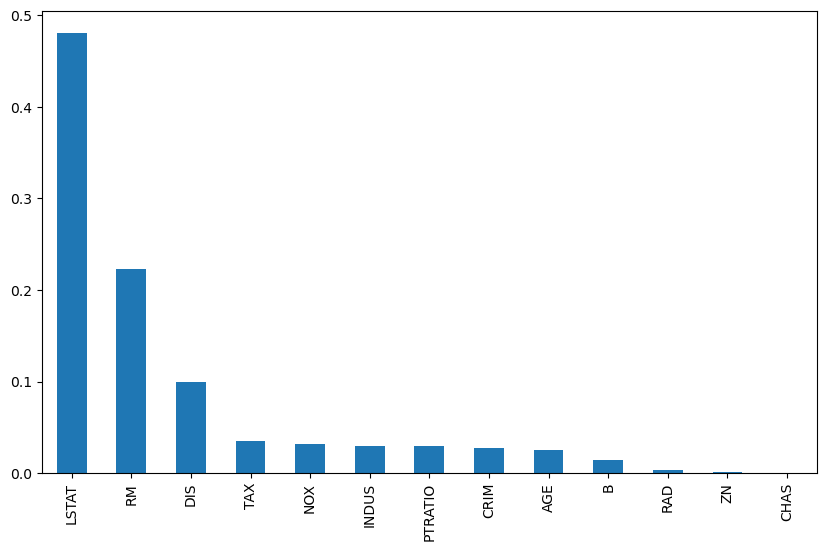

In [15]:
# feature importance
pd.Series(reg.feature_importances_,index = X_train.columns).sort_values(ascending=False).plot.bar(figsize = (10,6))

# XGB Classifier


In [16]:
xgb = XGBRegressor()
xgb.fit(X_train,y_train)
print('Training score is ',xgb.score(X_train,y_train))
print('Test score is ',xgb.score(X_test,y_test))

Training score is  0.9999999584482379
Test score is  0.8515522598415151


<Axes: >

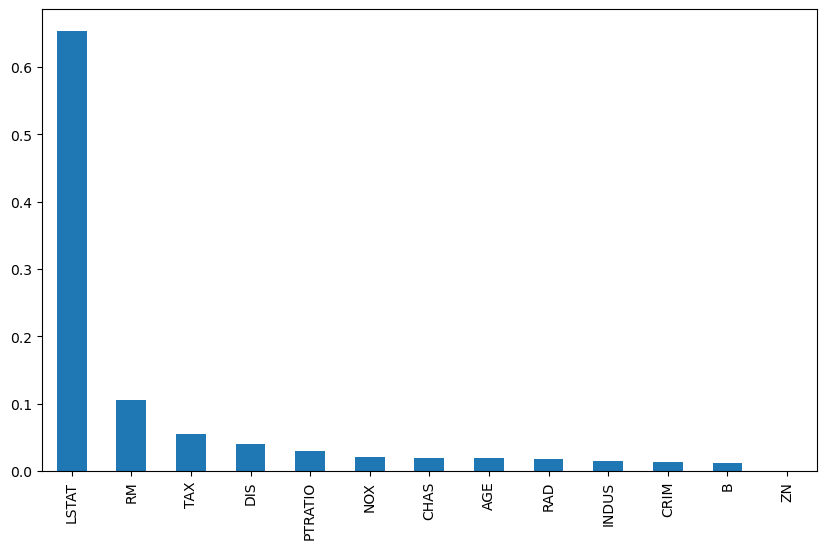

In [17]:
# feature importance
pd.Series(xgb.feature_importances_,index = X_train.columns).sort_values(ascending=False).plot.bar(figsize = (10,6))